In [108]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [109]:
import pandas as pd
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [110]:
df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")
print(df.shape)
df.head()

(2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [112]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [113]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


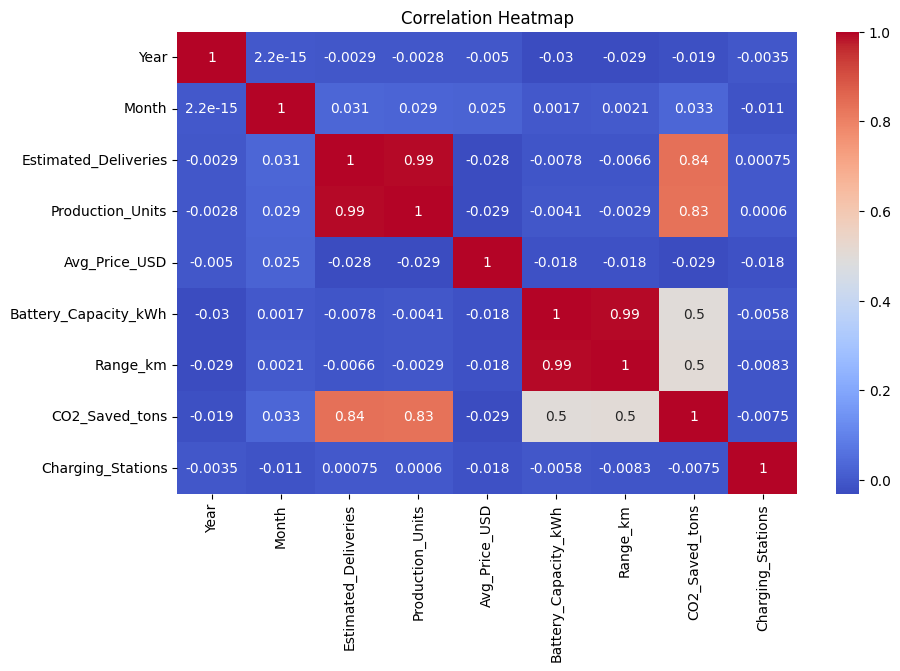

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

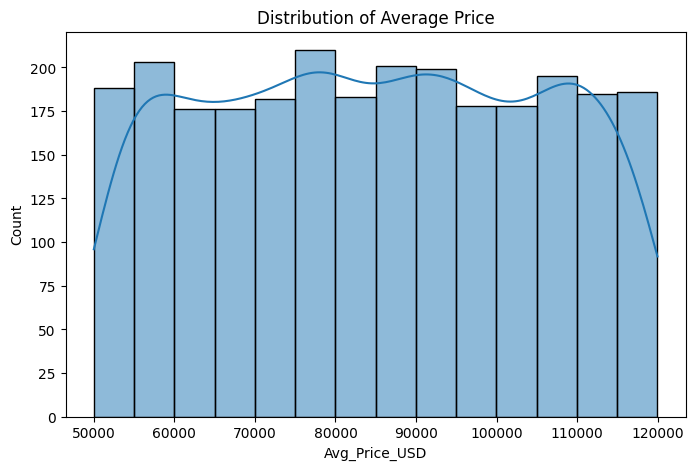

In [115]:
plt.figure(figsize=(8,5))

sns.histplot(df["Avg_Price_USD"], kde=True)

plt.title("Distribution of Average Price")
plt.show()

In [116]:
X = df.drop("Avg_Price_USD", axis=1)

y = df["Avg_Price_USD"]

print(X.shape)
print(y.shape)

(2640, 11)
(2640,)


In [117]:
num_cols = X.select_dtypes(
    include=['int64','float64']
).columns

cat_cols = X.select_dtypes(
    include=['object']
).columns

print("Numerical Columns:")
print(num_cols)

print("\nCategorical Columns:")
print(cat_cols)

Numerical Columns:
Index(['Year', 'Month', 'Estimated_Deliveries', 'Production_Units',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations'],
      dtype='object')

Categorical Columns:
Index(['Region', 'Model', 'Source_Type'], dtype='object')


In [118]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2112, 11)
(528, 11)


In [119]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

In [120]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            num_cols
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            cat_cols
        )
    ]
)

In [121]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

linear_pipeline.fit(
    X_train,
    y_train
)

print("Training Complete")

Training Complete


In [122]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pred = linear_pipeline.predict(X_test)

print("MAE :", mean_absolute_error(y_test, pred))
print("MSE :", mean_squared_error(y_test, pred))
print("R2  :", r2_score(y_test, pred))

MAE : 16822.648507442376
MSE : 380741239.9980116
R2  : -0.009621802206166485


In [123]:
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_train)

ridge_pred = ridge_pipeline.predict(X_test)

print("R2 Score:", r2_score(y_test, ridge_pred))
print("MAE:", mean_absolute_error(y_test, ridge_pred))

R2 Score: -0.009140923305599902
MAE: 16818.390432550445


In [124]:
from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(alpha=0.1))
])

lasso_pipeline.fit(X_train, y_train)

lasso_pred = lasso_pipeline.predict(X_test)

print("R2 Score:", r2_score(y_test, lasso_pred))
print("MAE:", mean_absolute_error(y_test, lasso_pred))

R2 Score: -0.009596546542880668
MAE: 16822.4652419375


In [125]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    linear_pipeline,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("CV Scores:", scores)
print("Average R2:", scores.mean())

CV Scores: [-0.01574286 -0.00387048 -0.00600153 -0.01576597  0.00200192]
Average R2: -0.007875784730978119


In [126]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

param_grid = {
    'model__alpha': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'model__alpha': 100}
Best Score: -0.0069398798693276476


In [127]:
df["Delivery_Production_Ratio"] = (
    df["Estimated_Deliveries"] /
    df["Production_Units"]
)

df["Price_per_kWh"] = (
    df["Avg_Price_USD"] /
    df["Battery_Capacity_kWh"]
)

df["Year_Month"] = (
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str)
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Delivery_Production_Ratio,Price_per_kWh,Year_Month
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,0.984600,773.952250,2023-5
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,0.911864,829.408667,2015-2
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,0.915334,1437.650244,2019-1
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,0.896594,744.124250,2021-2
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,0.914087,957.056500,2016-12


In [128]:
ts = df.groupby(
    ["Year", "Month"]
)["Estimated_Deliveries"].sum().reset_index()

ts["Date"] = pd.to_datetime(
    ts["Year"].astype(str)
    + "-"
    + ts["Month"].astype(str)
)

ts = ts.sort_values("Date")

ts.head()

,Year,Month,Estimated_Deliveries,Date
0,2015,1,183180,2015-01-01
1,2015,2,165053,2015-02-01
2,2015,3,184567,2015-03-01
3,2015,4,225623,2015-04-01
4,2015,5,184264,2015-05-01


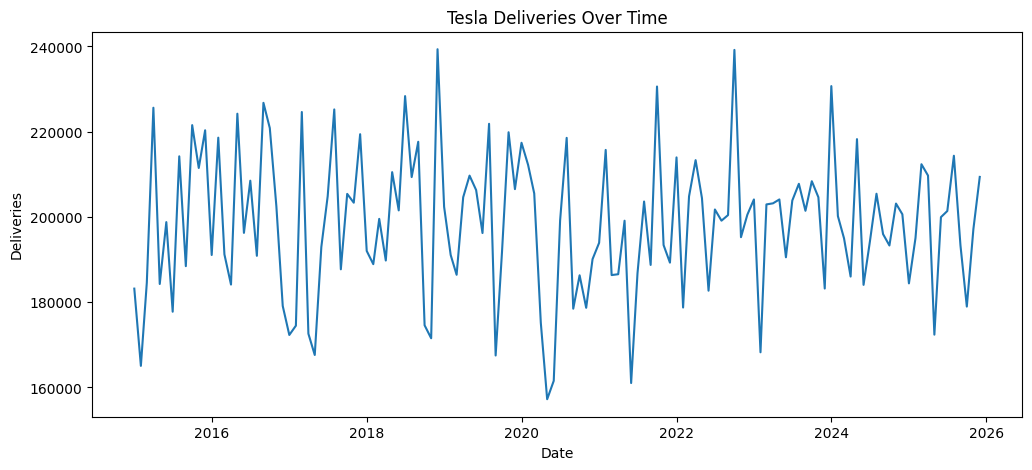

In [129]:
plt.figure(figsize=(12,5))

plt.plot(
    ts["Date"],
    ts["Estimated_Deliveries"]
)

plt.title("Tesla Deliveries Over Time")
plt.xlabel("Date")
plt.ylabel("Deliveries")

plt.show()

In [130]:
from sklearn.linear_model import LinearRegression
import numpy as np

ts["Time_Index"] = np.arange(len(ts))

X_ts = ts[["Time_Index"]]
y_ts = ts["Estimated_Deliveries"]

model = LinearRegression()
model.fit(X_ts, y_ts)

LinearRegression()

In [131]:
future_index = pd.DataFrame({
    "Time_Index": np.arange(
        len(ts),
        len(ts)+12
    )
})

future_pred = model.predict(future_index)

print(future_pred)

[198436.5710155  198436.45941537 198436.34781524 198436.2362151
 198436.12461497 198436.01301484 198435.90141471 198435.78981458
 198435.67821445 198435.56661432 198435.45501418 198435.34341405]


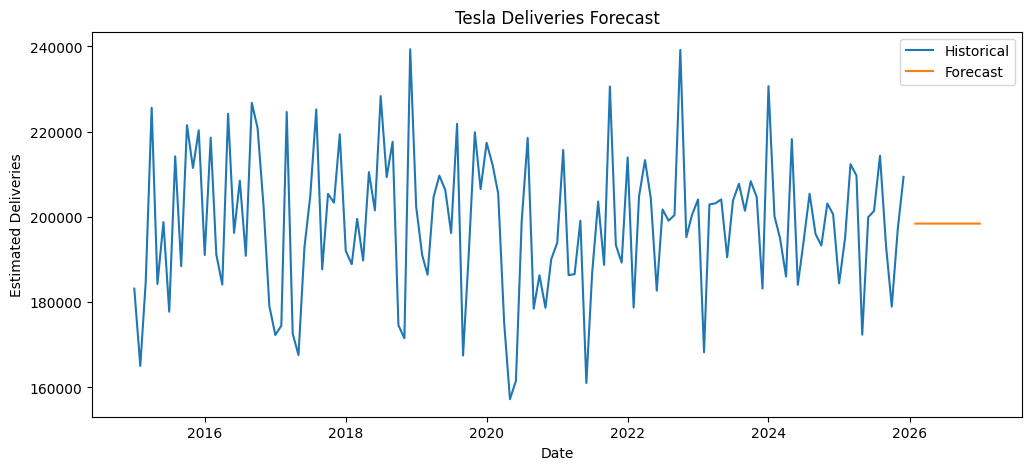

In [132]:
future_dates = pd.date_range(
    ts["Date"].max(),
    periods=13,
    freq="ME"
)[1:]

plt.figure(figsize=(12,5))

plt.plot(
    ts["Date"],
    ts["Estimated_Deliveries"],
    label="Historical"
)

plt.plot(
    future_dates,
    future_pred,
    label="Forecast"
)

plt.legend()
plt.title("Tesla Deliveries Forecast")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.show()